# CollisionVision — Training Hyperparameters, Explained

A technical, academic walkthrough of every section of `config.yaml` — the file that drives
`collision-vision train`. For each group we give the **what**, the **why**, and the
**mathematics** behind the setting.

Sections: **1** Model & data · **2** Core schedule · **3** Fine-tuning · **4** Optimizer ·
**5** Loss weights (segmentation) · **6** Augmentation.

> The code cells (LR schedule, DFL expectation, affine-on-polygon) are self-contained and
> only need `numpy` + `matplotlib`; run them top-to-bottom.

## 0. Notation and conventions

Throughout, we use the following symbols.

| Symbol | Meaning |
|---|---|
| $\theta$ | trainable model parameters (weights) |
| $g_t = \nabla_\theta \mathcal{L}$ | loss gradient at optimizer step $t$ |
| $\eta_t$ | learning rate at step $t$ |
| $B$ | mini-batch size (`batch`) |
| $N$ | number of training images |
| $E$ | number of epochs (`epochs`) |
| $T = E\lceil N/B \rceil$ | total number of optimizer updates |
| $\sigma(z)=1/(1+e^{-z})$ | logistic sigmoid |
| $\hat{p},\ \hat{y}$ | model predictions (probability / coordinate) |

Every key in `config.yaml` **except `model`** is forwarded verbatim to Ultralytics'
`YOLO(model).train(**cfg)`, so the names below map one-to-one onto the trainer API.

## 1. Model & data

```yaml
model: yolov8s-seg.pt
data:  data/processed/data.yaml
```

**`model` — the network being fine-tuned.** `yolov8s-seg.pt` is the *small* YOLOv8
**instance-segmentation** checkpoint. Architecturally it has three stages:

1. **Backbone** (CSP-Darknet): a convolutional feature extractor producing a pyramid of
   features at strides $8, 16, 32$.
2. **Neck** (PAN-FPN): top-down + bottom-up fusion so that small and large damage regions
   are both well represented.
3. **Decoupled head**: an *anchor-free* detector that, per grid cell, regresses a box and
   class logits, **plus** a segmentation branch.

**Prototype masks.** YOLOv8-Seg does not predict a full mask per instance directly. It
predicts $k$ **prototype masks** $P \in \mathbb{R}^{k \times H_m \times W_m}$ (shared across
the whole image) and, for each detected instance $i$, a coefficient vector
$\mathbf{c}_i \in \mathbb{R}^{k}$. The instance mask is their linear combination passed
through a sigmoid and then cropped to the predicted box:

$$
M_i = \sigma\!\left(\sum_{j=1}^{k} c_{ij}\, P_j\right), \qquad M_i \in [0,1]^{H_m \times W_m}.
$$

This factorization is what makes segmentation cheap: the expensive spatial maps $P_j$ are
computed **once** and reused for every instance in the image.

**`data` — dataset descriptor.** Points at the `data.yaml` emitted by
`collision-vision preprocess`, which lists the train/val image folders and the class names
(`0 = dent`, `1 = scratch`, `2 = structural`).

## 2. Core schedule

```yaml
epochs: 100     imgsz: 640      batch: 16
patience: 30    device:         workers: 8      seed: 0
```

**`epochs` / `batch` — how many updates.** One *epoch* is a full pass over the $N$ training
images. With mini-batch size $B$ there are $\lceil N/B \rceil$ gradient updates per epoch, so
the optimizer takes

$$
T = E \left\lceil \frac{N}{B} \right\rceil
$$

steps in total. This $T$ is exactly the horizon over which the LR schedule (§4) is stretched.

**Why batch size matters — a variance argument.** Mini-batch SGD estimates the true gradient
$\nabla\mathcal{L}$ by an average over $B$ i.i.d. samples:

$$
\hat{g} = \frac{1}{B}\sum_{i=1}^{B} \nabla\mathcal{L}_i,
\qquad
\operatorname{Var}[\hat{g}] = \frac{\sigma_g^2}{B}.
$$

Larger $B$ ⇒ lower-variance (smoother) gradients, but fewer updates per epoch and more
memory. $B = 16$ is a common single-GPU compromise.

**`imgsz: 640` — input resolution.** Images are letterboxed to $640\times640$. The three
detection heads then operate on grids of $80\times80$, $40\times40$ and $20\times20$
(strides $8/16/32$). The next cell counts the resulting prediction locations.

**`patience: 30` — early stopping.** Training halts if the validation fitness does not improve
for 30 consecutive epochs, guarding against overfitting and wasted compute.

**`device` / `workers` / `seed`.** `device` empty ⇒ auto-select GPU/CPU; `workers` is the
number of data-loading worker processes; `seed: 0` fixes the RNGs for reproducibility.

In [1]:
# How many predictions does a 640x640 input produce across the 3 detection heads?
imgsz = 640
strides = [8, 16, 32]           # P3, P4, P5

total = 0
for s in strides:
    g = imgsz // s              # feature-map side length
    n = g * g                   # one prediction per grid cell (anchor-free)
    total += n
    print(f"stride {s:>2}:  {g:>2} x {g:<2} grid  ->  {n:>5} locations")

print("-" * 38)
print(f"total prediction locations: {total}")

stride  8:  80 x 80 grid  ->   6400 locations
stride 16:  40 x 40 grid  ->   1600 locations
stride 32:  20 x 20 grid  ->    400 locations
--------------------------------------
total prediction locations: 8400


## 3. Fine-tuning

```yaml
pretrained: true
freeze: 10        # freeze the first 10 modules (backbone)
cos_lr: true      # cosine LR schedule
```

We are **not** training from scratch — we adapt COCO-pretrained weights to car damage.

**`pretrained: true`.** Initialize $\theta$ from the released `yolov8s-seg.pt` weights instead
of a random init. Transfer learning works because the backbone's low-level features (edges,
textures, curvature) are largely task-agnostic.

**`freeze: 10` — parameter freezing.** The first 10 modules (the backbone) are frozen: their
parameters receive **no gradient**, so they never move:

$$
\frac{\partial \mathcal{L}}{\partial \theta_{\text{frozen}}} := 0
\quad\Longrightarrow\quad
\theta_{\text{frozen}}^{(t+1)} = \theta_{\text{frozen}}^{(t)}.
$$

Only the neck and head are updated. With a small dataset this (i) sharply reduces the number
of trainable parameters, curbing overfitting, and (ii) preserves the general-purpose features
that a few hundred images could not re-learn.

**`cos_lr: true` — cosine annealing.** Selects the smooth cosine LR decay derived in §4 (as
opposed to a linear decay).

## 4. Optimizer

```yaml
optimizer: AdamW      lr0: 0.001      lrf: 0.01
momentum: 0.937       weight_decay: 0.0005
warmup_epochs: 3.0    warmup_momentum: 0.8
```

**AdamW = Adam + *decoupled* weight decay.** Adam keeps exponential moving averages of the
gradient (first moment $m_t$) and its element-wise square (second moment $v_t$):

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1)\, g_t, \\
v_t &= \beta_2 v_{t-1} + (1-\beta_2)\, g_t^{2}, \\
\hat{m}_t &= \frac{m_t}{1-\beta_1^{\,t}}, \qquad
\hat{v}_t = \frac{v_t}{1-\beta_2^{\,t}} \quad \text{(bias correction).}
\end{aligned}
$$

The parameter update uses a **per-coordinate** effective step size:

$$
\theta_t = \theta_{t-1} - \eta_t\!\left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
\; + \; \lambda\, \theta_{t-1}\right).
$$

Here $\beta_1 =$ `momentum` $= 0.937$ and $\lambda =$ `weight_decay` $= 5\times10^{-4}$. The
defining AdamW detail is that the decay term $\lambda\theta_{t-1}$ is added **outside** the
adaptive $1/\sqrt{\hat v}$ scaling (*decoupled*), so regularization strength is independent of
the gradient magnitude — unlike classic $L_2$-regularized Adam.

**`lr0` / `lrf` — cosine-annealed learning rate.** The base LR $\eta_0 =$ `lr0` decays to
$\eta_0\cdot$`lrf` over the run. With normalized progress $x = t/T \in [0,1]$:

$$
\eta(x) = \eta_0\Big[\underbrace{\tfrac{1}{2}\big(1+\cos(\pi x)\big)(1-\text{lrf}) + \text{lrf}}_{\text{cosine multiplier } lf(x)}\Big],
\qquad \eta(0)=\eta_0,\ \ \eta(1)=\eta_0\,\text{lrf}.
$$

**Warmup.** For the first `warmup_epochs` the LR ramps up **linearly from 0** and the momentum
from `warmup_momentum` $=0.8$ to $0.937$. This stabilizes the noisy early updates, when the
moment estimates $\hat m,\hat v$ are still poorly calibrated. The next cell plots the full
schedule.

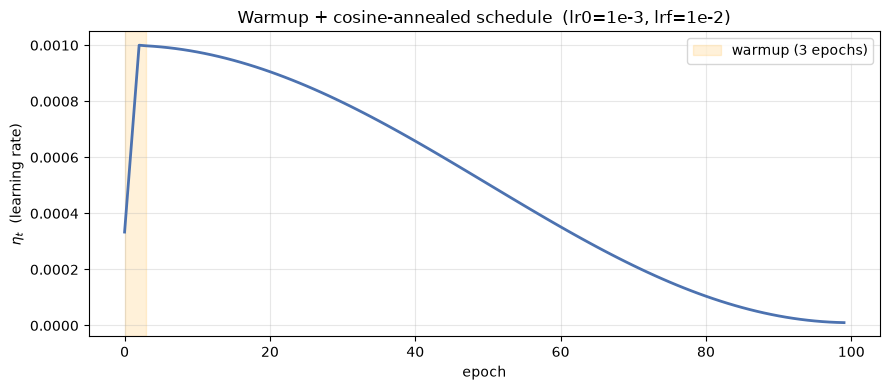

peak LR  = 1.00e-03
final LR = 1.02e-05  (= lr0 * lrf = 1e-05)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

epochs, lr0, lrf, warmup = 100, 1e-3, 0.01, 3.0
e = np.arange(epochs)

# Ultralytics "one_cycle" cosine multiplier: lf(0)=1 -> lf(E)=lrf
lf = (1 - np.cos(e * np.pi / epochs)) / 2 * (lrf - 1) + 1
lr_cosine = lr0 * lf

# linear warmup 0 -> lr0 during the first `warmup` epochs, then follow the cosine
lr = np.where(e < warmup, lr0 * (e + 1) / warmup, lr_cosine)
lr = np.minimum(lr, lr_cosine.max())          # cap the warmup ramp at the peak

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(e, lr, lw=2, color="#4C72B0")
ax.axvspan(0, warmup, color="orange", alpha=0.15, label=f"warmup ({warmup:g} epochs)")
ax.set_xlabel("epoch")
ax.set_ylabel(r"$\eta_t$  (learning rate)")
ax.set_title("Warmup + cosine-annealed schedule  (lr0=1e-3, lrf=1e-2)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print(f"peak LR  = {lr.max():.2e}")
print(f"final LR = {lr[-1]:.2e}  (= lr0 * lrf = {lr0 * lrf:.0e})")

## 5. Loss weights (segmentation)

```yaml
box: 7.5    cls: 0.5    dfl: 1.5
overlap_mask: true      mask_ratio: 4
```

YOLOv8-Seg minimizes a **weighted sum** of four terms; the `box/cls/dfl` gains set their
relative pull (the mask term carries a fixed internal weight):

$$
\mathcal{L} = \lambda_{\text{box}}\mathcal{L}_{\text{box}}
            + \lambda_{\text{cls}}\mathcal{L}_{\text{cls}}
            + \lambda_{\text{dfl}}\mathcal{L}_{\text{dfl}}
            + \mathcal{L}_{\text{seg}},
\qquad (\lambda_{\text{box}},\lambda_{\text{cls}},\lambda_{\text{dfl}}) = (7.5,\ 0.5,\ 1.5).
$$

**Box — CIoU loss.** Complete-IoU augments plain IoU with a center-distance term and an
aspect-ratio term:

$$
\mathcal{L}_{\text{box}} = 1 - \text{IoU} + \frac{\rho^2(\mathbf{b},\mathbf{b}^{gt})}{c^2} + \alpha v,
\quad
v = \frac{4}{\pi^2}\Big(\arctan\tfrac{w^{gt}}{h^{gt}} - \arctan\tfrac{w}{h}\Big)^2,
\quad
\alpha = \frac{v}{(1-\text{IoU})+v},
$$

where $\rho$ is the center distance and $c$ the diagonal of the smallest box enclosing both.

**DFL — Distribution Focal Loss.** Instead of regressing a box edge as a single scalar, each
edge is modeled as a **discrete distribution** $S=\text{softmax}(\cdot)$ over integer bins
$\{y_i\}$, and the prediction is its expectation $\hat{y} = \sum_i S_i\, y_i$. DFL sharpens that
distribution around the continuous target $y$ (with $y_i \le y \le y_{i+1}$):

$$
\mathcal{L}_{\text{dfl}} = -\big[(y_{i+1}-y)\log S_i + (y-y_i)\log S_{i+1}\big].
$$

**Classification — BCE.** Per-class binary cross-entropy over the assigned anchors:

$$
\mathcal{L}_{\text{cls}} = -\big[y\log\hat{p} + (1-y)\log(1-\hat{p})\big].
$$

**Segmentation.** Pixel-wise BCE between the assembled mask $M_i$ (§1) and the ground-truth
mask. **`overlap_mask: true`** stacks all instance masks into a single tensor
(memory-efficient; overlaps resolved by instance order), and **`mask_ratio: 4`** downsamples
the mask targets by $4\times$ to match the prototype resolution $H_m\times W_m$.

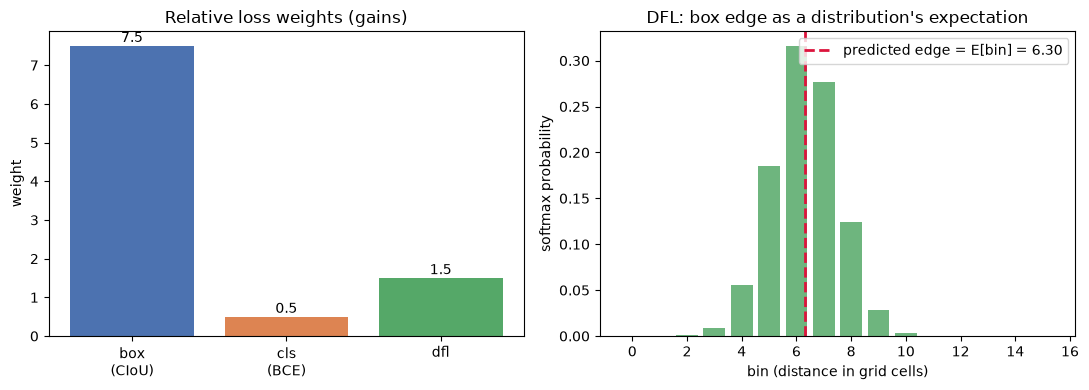

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# (a) relative loss-term weights
terms = ["box\n(CIoU)", "cls\n(BCE)", "dfl"]
gains = [7.5, 0.5, 1.5]
bars = ax[0].bar(terms, gains, color=["#4C72B0", "#DD8452", "#55A868"])
ax[0].set_title("Relative loss weights (gains)")
ax[0].set_ylabel("weight")
for b, g in zip(bars, gains):
    ax[0].text(b.get_x() + b.get_width() / 2, g + 0.1, str(g), ha="center")

# (b) DFL: a box edge is the expectation of a softmax over integer bins
bins = np.arange(0, 16)
logits = -((bins - 6.3) ** 2) / 3.0            # an example peaked prediction
p = np.exp(logits) / np.exp(logits).sum()
edge = float((p * bins).sum())                 # predicted coordinate = E[bin]
ax[1].bar(bins, p, color="#55A868", alpha=0.85)
ax[1].axvline(edge, color="crimson", ls="--", lw=2,
              label=f"predicted edge = E[bin] = {edge:.2f}")
ax[1].set_title("DFL: box edge as a distribution's expectation")
ax[1].set_xlabel("bin (distance in grid cells)")
ax[1].set_ylabel("softmax probability")
ax[1].legend()

fig.tight_layout()
plt.show()

## 6. Augmentation

```yaml
hsv_h: 0.015   hsv_s: 0.7      hsv_v: 0.4
degrees: 0.0   translate: 0.1  scale: 0.5   shear: 0.0   perspective: 0.0
flipud: 0.0    fliplr: 0.5
mosaic: 1.0    close_mosaic: 10   mixup: 0.0   copy_paste: 0.3
```

Augmentation multiplies the *effective* dataset size by applying **label-preserving** random
transforms each iteration — essential when only a few hundred labelled instances exist.

**Photometric — HSV jitter** (`hsv_h/s/v`). Convert to HSV and apply random gains
$g \sim \mathcal{U}(1-r,\ 1+r)$ per channel (hue is additive, modulo 180):

$$
H' = (H + \Delta H)\ \mathrm{mod}\ 180, \qquad S' = \mathrm{clip}(g_s\, S), \qquad V' = \mathrm{clip}(g_v\, V).
$$

This models lighting and paint-colour variation without moving any mask vertex.

**Geometric — affine** (`degrees, translate, scale, shear, perspective`). A random homogeneous
transform is applied to the image **and** to every polygon vertex:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix}
= T\, Sh\, S\, R \begin{bmatrix} x \\ y \\ 1 \end{bmatrix},
\quad
R=\begin{bmatrix}\cos\phi & -\sin\phi & 0\\ \sin\phi & \cos\phi & 0\\ 0&0&1\end{bmatrix},
\ \
S=\begin{bmatrix}s&0&0\\0&s&0\\0&0&1\end{bmatrix},
\ \
Sh=\begin{bmatrix}1&\tan\psi&0\\0&1&0\\0&0&1\end{bmatrix}.
$$

Here rotation and shear are disabled (`degrees = shear = 0`), while $\pm10\%$ translation and
$\pm50\%$ scale are active — damage can appear anywhere and at any size.

**Flips.** `fliplr: 0.5` mirrors horizontally with probability $0.5$ (a car is roughly symmetric
left↔right); `flipud: 0.0` disables vertical flips (upside-down cars are unrealistic).

**Mosaic & MixUp.** `mosaic: 1.0` stitches **4 images** into one, exposing the model to many
scales and contexts per step; `close_mosaic: 10` **turns mosaic off for the last 10 epochs** so
training finishes on clean, undistorted images. MixUp blends two images,
$\tilde{x} = \lambda x_i + (1-\lambda)x_j$ with $\lambda \sim \mathrm{Beta}(\alpha,\alpha)$, and
is **disabled** here (`mixup: 0.0`).

**`copy_paste: 0.3` — the segmentation-specific one.** With probability $0.3$ it cuts an instance
out along its **mask** and pastes it into another image. It requires pixel-accurate masks (which
we have) and directly attacks class imbalance by manufacturing extra
`structural` / `dent` / `scratch` instances.

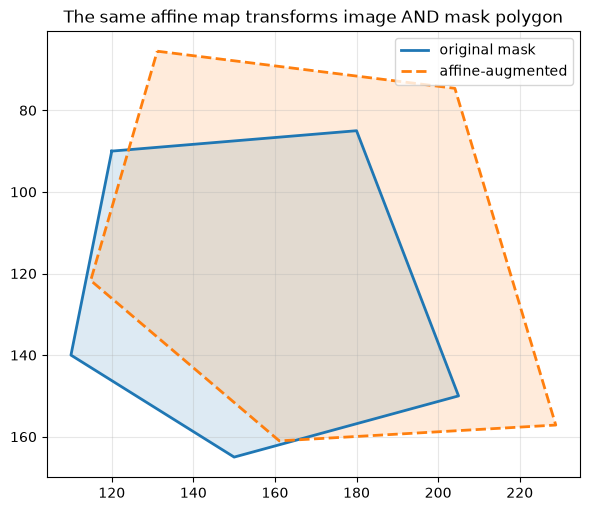

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# a toy "damage" polygon (pixel coordinates)
poly = np.array([[120, 90], [180, 85], [205, 150], [150, 165], [110, 140]], float)

def affine(degrees=0.0, scale=1.0, shear=0.0, translate=(0.0, 0.0)):
    a, sh = np.deg2rad(degrees), np.deg2rad(shear)
    R  = np.array([[np.cos(a), -np.sin(a), 0], [np.sin(a), np.cos(a), 0], [0, 0, 1]])
    S  = np.diag([scale, scale, 1.0])
    Sh = np.array([[1, np.tan(sh), 0], [0, 1, 0], [0, 0, 1]])
    T  = np.array([[1, 0, translate[0]], [0, 1, translate[1]], [0, 0, 1]])
    return T @ Sh @ S @ R          # compose: rotate -> scale -> shear -> translate

def apply(M, pts):
    h = np.c_[pts, np.ones(len(pts))]
    return (h @ M.T)[:, :2]

c = poly.mean(0)                                # transform about the centroid
M = affine(degrees=12, scale=1.2, shear=8, translate=(15, -10))
aug = apply(M, poly - c) + c

plt.figure(figsize=(6, 6))
for P, lbl, st in [(poly, "original mask", "-"), (aug, "affine-augmented", "--")]:
    Q = np.vstack([P, P[0]])                     # close the polygon
    plt.fill(Q[:, 0], Q[:, 1], alpha=0.15)
    plt.plot(Q[:, 0], Q[:, 1], st, lw=2, label=lbl)

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()                         # image coords: y grows downward
plt.title("The same affine map transforms image AND mask polygon")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary — why these values, together

The configuration is internally consistent for **fine-tuning a small segmentation model**:

| Group | Key settings | Purpose |
|---|---|---|
| Model & data | `yolov8s-seg.pt`, prototype masks | compact, fast instance segmentation |
| Schedule | `epochs=100`, `batch=16`, `imgsz=640`, `patience=30` | enough updates + early-stop safety net |
| Fine-tuning | `pretrained`, `freeze=10`, `cos_lr` | reuse backbone, few trainable parameters |
| Optimizer | `AdamW`, `lr0=1e-3`, `lrf=0.01`, `warmup=3` | stable low-LR adaptation, decays to $10^{-5}$ |
| Loss | `box=7.5`, `cls=0.5`, `dfl=1.5` | box-accuracy-weighted, DFL-refined edges |
| Augmentation | affine + flip + mosaic + `copy_paste=0.3` | stretch a tiny dataset; mask-aware paste |

**The through-line:** a limited dataset drives every choice — freeze the backbone, keep the LR
low with a long warmup, weight the box/mask terms we actually care about, and lean heavily on
augmentation (especially mask-aware `copy_paste`) to synthesize variety.

> All values are forwarded to Ultralytics `train()`. To experiment, edit
> [`config.yaml`](../config.yaml) or override on the CLI, e.g.
> `collision-vision train --config config.yaml --lr0 5e-4 --epochs 50`.